In [1]:
!pip install opendatasets opencv-python albumentations lime shap scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d8e887842fa5fcc0b0b42f99ae5328da9924d3d3a23c298716967442122ccc72
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [15]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
import warnings
import tensorflow as tf
import albumentations as A
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50, DenseNet121, Xception
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.applications import ResNet50, DenseNet121, Xception
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    concatenate,
    Average
)
from tensorflow.keras.models import Model
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import opendatasets as od
ham_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
isic_url = "https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic"

print("Downloading HAM10000...")
od.download(ham_url)
print("Downloading ISIC 9 Classes...")
od.download(isic_url)

master_dir = 'unified_dataset'
os.makedirs(master_dir, exist_ok=True)

ham_mapping = {'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
               'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
               'vasc': 'vascular_lesion'}

isic_mapping = {'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
                'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
                'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
                'squamous cell carcinoma': 'actinic_keratosis', 'vascular lesion': 'vascular_lesion'}

ham_base = 'skin-cancer-mnist-ham10000'
metadata = pd.read_csv(f'{ham_base}/HAM10000_metadata.csv')
ham_folders = [f'{ham_base}/ham10000_images_part_1', f'{ham_base}/ham10000_images_part_2']

print("Processing HAM10000...")
for _, row in metadata.iterrows():
    label = ham_mapping[row['dx']]
    dest = os.path.join(master_dir, label)
    os.makedirs(dest, exist_ok=True)
    img_name = row['image_id'] + '.jpg'
    for folder in ham_folders:
        src = os.path.join(folder, img_name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest, img_name))
            break

print("Processing ISIC 9 Classes...")
isic_root = 'skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
for split in ['Train', 'Test']:
    split_path = os.path.join(isic_root, split)
    if not os.path.exists(split_path): continue
    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            dest_folder = os.path.join(master_dir, target_label)
            os.makedirs(dest_folder, exist_ok=True)
            src_folder = os.path.join(split_path, folder_name)
            for img in os.listdir(src_folder):
                safe_img_name = f"isic9_{split.lower()}_{img}"
                shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, safe_img_name))

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnasser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:32<00:00, 171MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnasser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic


100%|██████████| 786M/786M [00:08<00:00, 96.8MB/s]



Processing HAM10000...
Processing ISIC 9 Classes...


In [4]:
balanced_dir = 'balanced_dataset'
TARGET_COUNT = 2000

if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir)

transform = A.Compose([
    A.Resize(192, 192),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=25,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.CLAHE(p=0.3),
])

print("Balancing classes to 2000 images each...")
for class_name in os.listdir(master_dir):
    src_dir = os.path.join(master_dir, class_name)
    dst_dir = os.path.join(balanced_dir, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    images = [img for img in os.listdir(src_dir) if img.endswith(('.jpg','.png','.jpeg'))]

    if len(images) >= TARGET_COUNT:
        selected = random.sample(images, TARGET_COUNT)
        for img in selected:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))
    else:
        for img in images:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))

        while len(os.listdir(dst_dir)) < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(src_dir, img_name)

            img = cv2.imread(img_path)
            if img is None: continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            aug = transform(image=img)['image']
            aug = cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)

            new_name = f"aug_{random.randint(0,999999)}.jpg"
            cv2.imwrite(os.path.join(dst_dir, new_name), aug)

Balancing classes to 2000 images each...


In [6]:
def remove_hair(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img, thresh, 1, cv2.INPAINT_TELEA)


clean_dir = 'clean_dataset'
drive_zip_path = '/content/drive/MyDrive/clean_dataset_backup.zip'
os.makedirs(clean_dir, exist_ok=True)

print("Applying Blackhat Hair Removal...")
for class_name in os.listdir(balanced_dir):
    src = os.path.join(balanced_dir, class_name)
    dst = os.path.join(clean_dir, class_name)
    os.makedirs(dst, exist_ok=True)

    for img_name in os.listdir(src):
        img = cv2.imread(os.path.join(src, img_name))
        if img is None: continue
        img = remove_hair(img)
        cv2.imwrite(os.path.join(dst, img_name), img)

shutil.make_archive('clean_dataset_backup', 'zip', clean_dir)
shutil.copy('clean_dataset_backup.zip', drive_zip_path)
print("Backup saved successfully!")

Applying Blackhat Hair Removal...
Backup saved successfully!


In [10]:
train_dir = "train"
val_dir = "val"
test_dir = "test"

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

classes = sorted(os.listdir(clean_dir))

print("Splitting dataset into Train/Val/Test...")
for c in classes:
    imgs = os.listdir(os.path.join(clean_dir, c))
    train, temp = train_test_split(imgs, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for d, split in zip([train_dir, val_dir, test_dir], [train, val, test]):
        os.makedirs(os.path.join(d, c), exist_ok=True)
        for img in split:
            shutil.copy2(os.path.join(clean_dir, c, img), os.path.join(d, c, img))

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32)
val_data = val_gen.flow_from_directory(val_dir, target_size=(224,224), batch_size=32, shuffle=False)
test_data = test_gen.flow_from_directory(test_dir, target_size=(224,224), batch_size=32, shuffle=False)

NUM_CLASSES = train_data.num_classes
class_names = list(train_data.class_indices.keys())


Splitting dataset into Train/Val/Test...
Found 9800 images belonging to 7 classes.
Found 2100 images belonging to 7 classes.
Found 2100 images belonging to 7 classes.


In [33]:
def build_model():
    input_tensor = Input(shape=(224,224,3))
    base_resnet = ResNet50(weights='imagenet', include_top=False, name='resnet50_branch')
    base_xcep   = Xception(weights='imagenet', include_top=False, name='xception_branch')
    base_dense  = DenseNet121(weights='imagenet', include_top=False, name='densenet121_branch')

    resnet_features = base_resnet(input_tensor)
    xcep_features = base_xcep(input_tensor)
    dense_features = base_dense(input_tensor)

    for base in [base_resnet, base_xcep, base_dense]:
        base.trainable = False

    f1 = GlobalAveragePooling2D()(resnet_features)
    f2 = GlobalAveragePooling2D()(xcep_features)
    f3 = GlobalAveragePooling2D()(dense_features)

    fused = concatenate([f1, f2, f3])

    fused = BatchNormalization()(fused)
    fused = Dense(1024, activation='relu')(fused)
    fused = Dropout(0.5)(fused)

    fused = Dense(512, activation='relu')(fused)
    fused = Dropout(0.3)(fused)

    output = Dense(NUM_CLASSES, activation='softmax')(fused)

    model = Model(inputs=input_tensor, outputs=output)

    return model, [base_resnet, base_xcep, base_dense]

In [32]:
model, base_models = build_model()

In [34]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))

In [36]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model, base_models = build_model()

model.compile(optimizer=Adam(3e-4), loss=loss_fn, metrics=['accuracy'])

In [37]:
drive_model_path = "/content/drive/MyDrive/best_dermoexpert.keras"

cb = [
    callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=4, factor=0.3),
    callbacks.ModelCheckpoint(drive_model_path, save_best_only=True)
]

In [38]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=cb
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 299s 823ms/step - accuracy: 0.4459 - loss: 1.7808 - val_accuracy: 0.5310 - val_loss: 1.3696 - learning_rate: 3.0000e-04
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 193s 627ms/step - accuracy: 0.5477 - loss: 1.4098 - val_accuracy: 0.5805 - val_loss: 1.3226 - learning_rate: 3.0000e-04
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 197s 639ms/step - accuracy: 0.5732 - loss: 1.3333 - val_accuracy: 0.6048 - val_loss: 1.2835 - learning_rate: 3.0000e-04
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 193s 628ms/step - accuracy: 0.5958 - loss: 1.2910 - val_accuracy: 0.6105 - val_loss: 1.2420 - learning_rate: 3.0000e-04
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 194s 632ms/step - accuracy: 0.6147 - loss: 1.2482 - val_accuracy: 0.6286 - val_loss: 1.2345 - learning_rate: 3.0000e-04
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 187s 609ms/step - accuracy: 0.6256 - loss: 1.2258 - val_accuracy: 0.6110 - val_loss: 1.2445 - learning_rate: 3.0000e-04
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 

In [39]:
for base in base_models:
    base.trainable = True
    for layer in base.layers[:int(len(base.layers)*0.8)]:
        layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss=loss_fn, metrics=['accuracy'])

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=cb
)

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 407s 953ms/step - accuracy: 0.6845 - loss: 1.1350 - val_accuracy: 0.6667 - val_loss: 1.1349 - learning_rate: 1.0000e-05
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 200s 652ms/step - accuracy: 0.7362 - loss: 1.0275 - val_accuracy: 0.6976 - val_loss: 1.0704 - learning_rate: 1.0000e-05
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 201s 655ms/step - accuracy: 0.7547 - loss: 0.9846 - val_accuracy: 0.7152 - val_loss: 1.0446 - learning_rate: 1.0000e-05
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 217s 703ms/step - accuracy: 0.7806 - loss: 0.9493 - val_accuracy: 0.7243 - val_loss: 1.0314 - learning_rate: 1.0000e-05
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 258s 689ms/step - accuracy: 0.7929 - loss: 0.9202 - val_accuracy: 0.7381 - val_loss: 1.0074 - learning_rate: 1.0000e-05
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 229s 744ms/step - accuracy: 0.8061 - loss: 0.8970 - val_accuracy: 0.7414 - val_loss: 0.9960 - learning_rate: 1.0000e-05
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 

In [40]:
best_model = tf.keras.models.load_model(drive_model_path)
loss, acc = best_model.evaluate(test_data)
print(f"Test Accuracy: {acc*100:.2f}%")



66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 544ms/step - accuracy: 0.8048 - loss: 0.8920
Test Accuracy: 80.48%


In [41]:
y_pred = best_model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred, target_names=class_names))

66/66 ━━━━━━━━━━━━━━━━━━━━ 65s 671ms/step
                      precision    recall  f1-score   support

   actinic_keratosis       0.78      0.70      0.74       300
basal_cell_carcinoma       0.82      0.71      0.76       300
    benign_keratosis       0.72      0.78      0.75       300
      dermatofibroma       0.86      0.93      0.89       300
    melanocytic_nevi       0.81      0.84      0.83       300
            melanoma       0.69      0.68      0.68       300
     vascular_lesion       0.97      0.98      0.98       300

            accuracy                           0.80      2100
           macro avg       0.80      0.80      0.80      2100
        weighted avg       0.80      0.80      0.80      2100



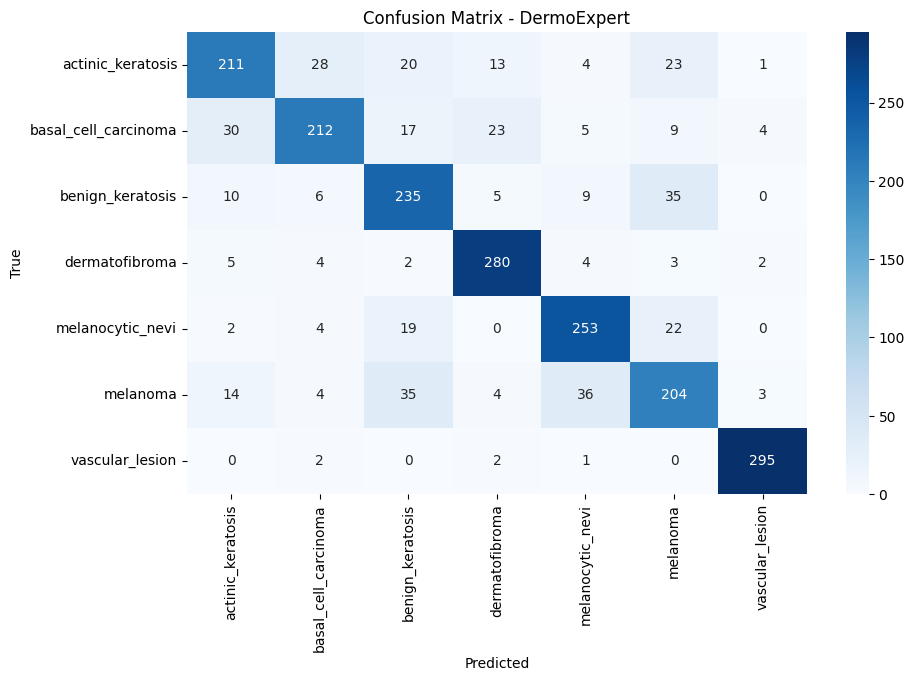

In [42]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - DermoExpert")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [53]:
sample_class = class_names[0]

sample_img_name = os.listdir(
    os.path.join(test_dir, sample_class)
)[0]

test_img_path = os.path.join(
    test_dir,
    sample_class,
    sample_img_name
)

In [54]:
def prep_img_for_xai(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224, 224))
    original_img = img.copy()

    img = img.astype(np.float32)

    processed_img = preprocess_input(img)


    processed_img = np.expand_dims(processed_img, axis=0)

    return original_img, processed_img

In [55]:
def run_lime(img_path, model):

    original_img, processed_img = prep_img_for_xai(img_path)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        original_img.astype(np.double),
        classifier_fn=lambda x: model.predict(
            preprocess_input(x.copy())
        ),
        top_labels=3,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))

    plt.imshow(mark_boundaries(temp / 255.0, mask))

    plt.title(
        f"1. LIME - Predicted: "
        f"{class_names[explanation.top_labels[0]]}"
    )

    plt.axis('off')
    plt.show()


In [56]:
def run_gradcam(
    img_path,
    model,
    last_conv_layer_name='conv5_block3_out'
):

    original_img, processed_img = prep_img_for_xai(img_path)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(processed_img)

        pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)


    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    heatmap = heatmap.numpy()


    heatmap = cv2.resize(
        heatmap,
        (224, 224)
    )


    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    superimposed_img = (
        heatmap * 0.4 +
        original_img
    )

    superimposed_img = np.clip(
        superimposed_img / 255.0,
        0,
        1
    )

    plt.figure(figsize=(6,6))

    plt.imshow(superimposed_img)

    plt.title(
        f"2. Grad-CAM\n"
        f"Predicted: {class_names[pred_index]}"
    )

    plt.axis('off')
    plt.show()

In [57]:
def run_shap(img_path, model, bg_data_gen):

    original_img, processed_img = prep_img_for_xai(img_path)

    bg_images, _ = next(bg_data_gen)

    bg_images = bg_images[:20]

    explainer = shap.GradientExplainer(
        model,
        bg_images
    )

    shap_values = explainer.shap_values(
        processed_img
    )

    print("3. SHAP Explanation")

    shap.image_plot(
        shap_values,
        processed_img
    )

In [58]:
def run_saliency(img_path, model):

    original_img, processed_img = prep_img_for_xai(img_path)

    img_tensor = tf.convert_to_tensor(
        processed_img
    )

    with tf.GradientTape() as tape:

        tape.watch(img_tensor)

        predictions = model(img_tensor)

        top_class = tf.argmax(predictions[0])

        top_class_score = predictions[:, top_class]

    grads = tape.gradient(
        top_class_score,
        img_tensor
    )

    saliency = tf.reduce_max(
        tf.abs(grads),
        axis=-1
    )[0]

    saliency = saliency.numpy()

    saliency = (
        saliency - saliency.min()
    ) / (
        saliency.max() -
        saliency.min() +
        1e-8
    )

    plt.figure(figsize=(6,6))

    plt.imshow(
        saliency,
        cmap='hot'
    )

    plt.title(
        f"4. Saliency Map\n"
        f"Class: {class_names[top_class.numpy()]}"
    )

    plt.axis('off')

    plt.colorbar()

    plt.show()

Generating XAI Visualizations...


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

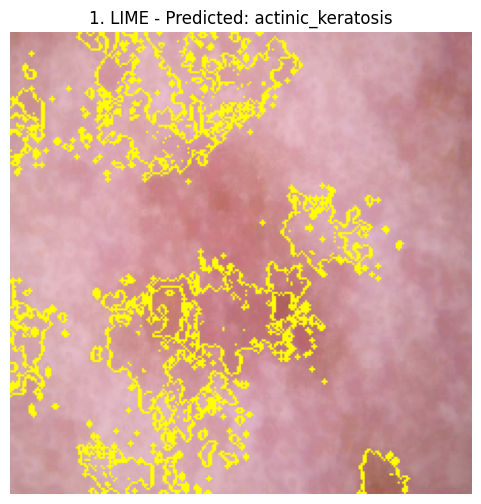

3. SHAP Explanation


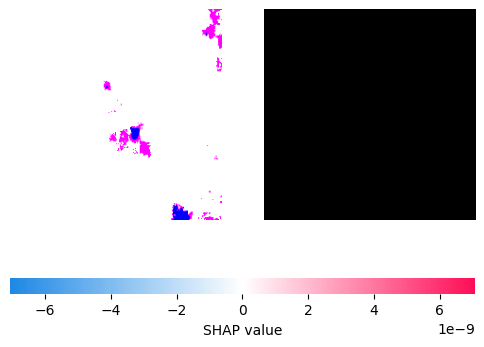

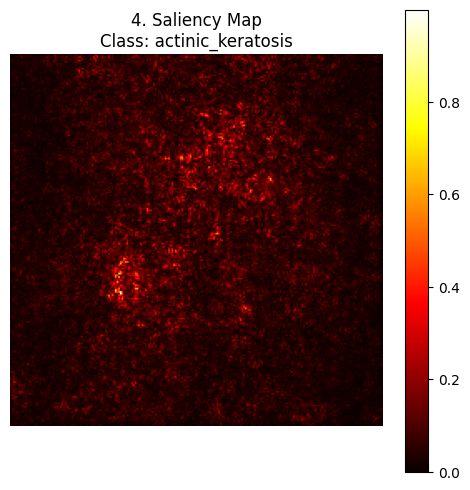

In [60]:
print("Generating XAI Visualizations...")

run_lime(test_img_path, best_model)

# run_gradcam(
#     test_img_path,
#     best_model,
#     last_conv_layer_name='conv5_block3_out'
# )

run_shap(
    test_img_path,
    best_model,
    val_data
)

run_saliency(
    test_img_path,
    best_model
)